# Online Retail II — Notebook 2: Exploratory Analysis & Insights

*Second of two notebooks.* [Notebook 1](01_data_preparation.ipynb) assessed data quality and
saved a clean, analysis-ready dataset. Here we explore it and tell the story the data supports —
from headline commercial patterns to customer segments, retention, product affinity, and a first
predictive baseline.

**The arc:** where the money is (time, geography, customers, products) → who the customers are
and whether they come back → what sells together → can we predict repeat purchase → findings and
recommendations. Every number is produced by a visible cell.

## Setup & the analysis views

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
from itertools import combinations
from collections import Counter
import numpy as np, pandas as pd, re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

NAVY, TEAL, LBLUE, CORAL, GRAY = "#14213D", "#0FA3B1", "#7DCFDD", "#E07A5F", "#9AA5B1"
plt.rcParams.update({
    "figure.figsize": (9, 4.4), "figure.dpi": 110, "font.size": 11,
    "axes.titleweight": "bold", "axes.titlecolor": NAVY, "axes.labelcolor": NAVY,
    "axes.edgecolor": GRAY, "axes.grid": True, "grid.color": "#ECEFF2",
    "text.color": NAVY, "xtick.color": NAVY, "ytick.color": NAVY,
    "axes.spines.top": False, "axes.spines.right": False,
})
money = lambda x, _=None: (f"£{x/1e6:.1f}M" if abs(x) >= 1e6 else f"£{x/1e3:.0f}k")

# Load the prepared dataset from Notebook 1.
prep = pd.read_parquet(Path("..") / "data" / "online_retail_prepared.parquet")

# Three analysis views used throughout: clean merchandise SALES, merchandise RETURNS,
# and (for customer-level work) the subset of sales that has a Customer ID.
sales   = prep[(prep["nature"] == "Merchandise") & (~prep["is_cancellation"]) &
               (prep["Quantity"] > 0) & (prep["Price"] > 0)].copy()
returns = prep[(prep["nature"] == "Merchandise") & (prep["is_cancellation"])].copy()
print(f"merchandise sales : {len(sales):,} lines, £{sales['Revenue'].sum():,.0f}")
print(f"merchandise returns: {len(returns):,} lines, £{returns['Revenue'].sum():,.0f}")
print(f"identified customers: {sales['Customer ID'].nunique():,} "
      f"({sales['Customer ID'].isna().mean()*100:.0f}% of sale lines have no customer)")

merchandise sales : 1,003,357 lines, £19,643,862
merchandise returns: 17,915 lines, £-716,463
identified customers: 5,852 (23% of sale lines have no customer)


## 1. Revenue over time & seasonality

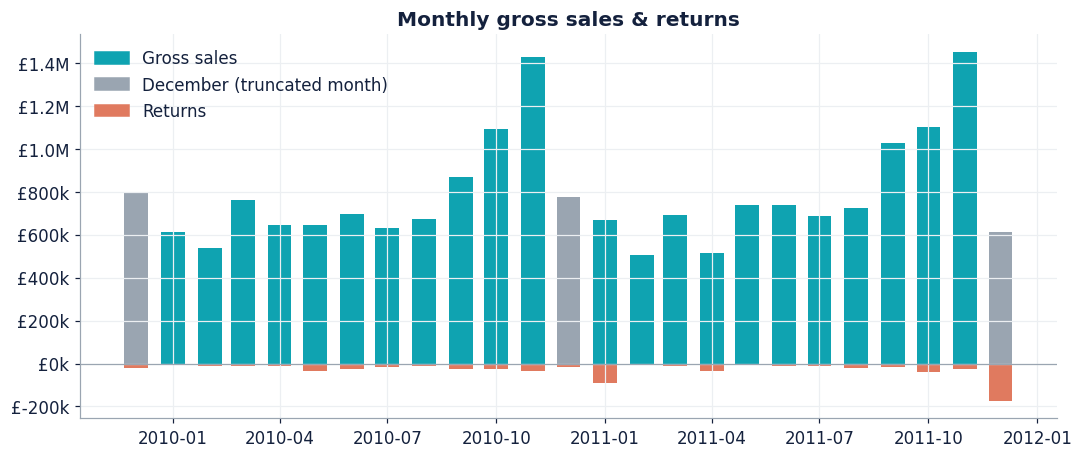

In [2]:
# Monthly gross sales + returns. December bars are greyed because every December is a
# truncated (partial) month — the business closes ~23 Dec — so they are not comparable.
from matplotlib.patches import Patch
sales["month"] = sales["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
sales["date"]  = sales["InvoiceDate"].dt.date
returns["month"] = returns["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
m_rev = sales.groupby("month")["Revenue"].sum()
m_ret = returns.groupby("month")["Revenue"].sum().reindex(m_rev.index).fillna(0)
colors = [GRAY if m == 12 else TEAL for m in m_rev.index.month]

fig, ax = plt.subplots(figsize=(10, 4.3))
ax.bar(m_rev.index, m_rev.values, width=20, color=colors)
ax.bar(m_ret.index, m_ret.values, width=20, color=CORAL)
ax.axhline(0, color=GRAY, lw=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money))
ax.legend(handles=[Patch(color=TEAL, label="Gross sales"),
                   Patch(color=GRAY, label="December (truncated month)"),
                   Patch(color=CORAL, label="Returns")], frameon=False, loc="upper left")
ax.set_title("Monthly gross sales & returns")
plt.tight_layout(); plt.show()

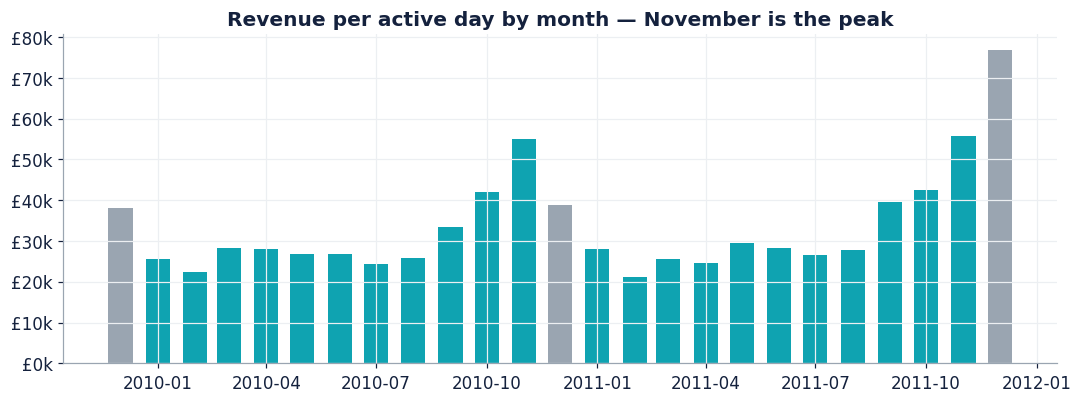

  2010-11: £55k/day over 26 active days
  2010-12: £39k/day over 20 active days
  2011-11: £56k/day over 26 active days
  2011-12: £77k/day over 8 active days


In [3]:
# Normalise for month length: revenue per ACTIVE day (revenue / days that actually had sales).
mday = (sales.assign(ym=sales["InvoiceDate"].dt.to_period("M"))
             .groupby("ym").agg(rev=("Revenue", "sum"), days=("date", "nunique")))
mday["per_day"] = mday["rev"] / mday["days"]
idx = mday.index.to_timestamp()
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(idx, mday["per_day"].values, width=20,
       color=[GRAY if t.month == 12 else TEAL for t in idx])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money))
ax.set_title("Revenue per active day by month — November is the peak")
plt.tight_layout(); plt.show()
for ym in ["2010-11", "2010-12", "2011-11", "2011-12"]:
    print(f"  {ym}: £{mday.loc[ym,'per_day']/1e3:.0f}k/day over {int(mday.loc[ym,'days'])} active days")

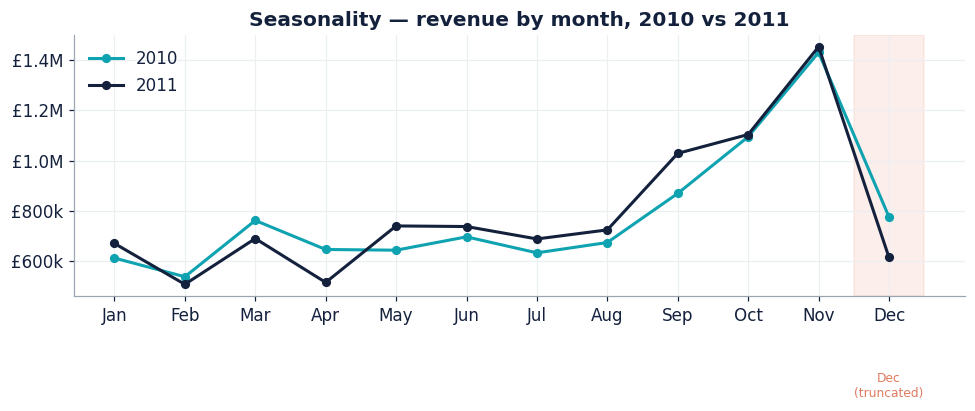

In [4]:
# Seasonality profile: revenue by month-of-year, 2010 vs 2011 (the two fuller years).
prof = (sales.assign(year=sales["InvoiceDate"].dt.year, moy=sales["InvoiceDate"].dt.month)
             .groupby(["year", "moy"])["Revenue"].sum().unstack(0))
mnames = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(9, 4.2))
for yr, col in [(2010, TEAL), (2011, NAVY)]:
    if yr in prof.columns:
        ax.plot(range(1,13), prof[yr].reindex(range(1,13)).values, marker="o", ms=5, lw=2, color=col, label=str(yr))
ax.axvspan(11.5, 12.5, color=CORAL, alpha=0.12)
ax.text(12, ax.get_ylim()[1]*0.04, "Dec\n(truncated)", color=CORAL, ha="center", fontsize=8)
ax.set_xticks(range(1,13)); ax.set_xticklabels(mnames)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money))
ax.set_title("Seasonality — revenue by month, 2010 vs 2011"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

Demand builds through autumn to a **November peak** in both years. December cannot be read as a
peak: the business closes around 23 December (so late-December is never observed), and — as
flagged in Notebook 1 — 2010's December is distorted by a duplicate-row cluster. Returns (coral)
are small relative to sales, but present every month.

## 2. Geographic concentration

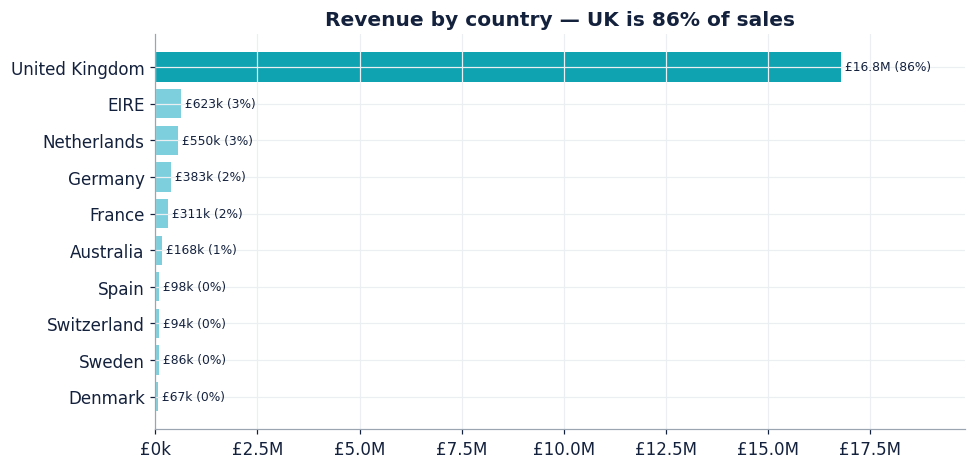

UK is 92% of ORDERS but 86% of REVENUE -> overseas orders are larger on average.


In [5]:
by_country = sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
uk_rev = by_country["United Kingdom"] / by_country.sum() * 100
uk_ord = sales[sales["Country"]=="United Kingdom"]["Invoice"].nunique() / sales["Invoice"].nunique() * 100
top = by_country.head(10)[::-1]
fig, ax = plt.subplots()
ax.barh(top.index, top.values, color=[TEAL if c=="United Kingdom" else LBLUE for c in top.index])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
for i,(c,v) in enumerate(top.items()):                       # value + % label on each bar
    ax.text(v, i, f" {money(v)} ({v/by_country.sum()*100:.0f}%)", va="center", fontsize=8, color=NAVY)
ax.set_xlim(0, top.max()*1.18); ax.set_title(f"Revenue by country — UK is {uk_rev:.0f}% of sales")
plt.tight_layout(); plt.show()
print(f"UK is {uk_ord:.0f}% of ORDERS but {uk_rev:.0f}% of REVENUE -> overseas orders are larger on average.")

## 3. Customers

### 3a. Revenue concentration (Pareto)

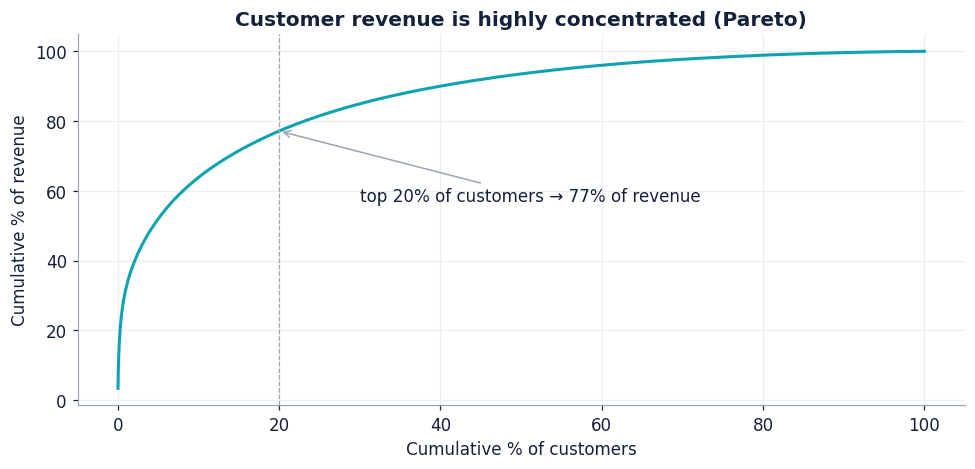

5,852 identified customers | top 20% = 77% of revenue | median £856 | mean £2,917


In [6]:
# Cumulative revenue vs cumulative customers (identified customers only).
cust_rev = (sales.dropna(subset=["Customer ID"]).groupby("Customer ID")["Revenue"].sum()
                 .sort_values(ascending=False))
cum = (cust_rev.cumsum()/cust_rev.sum()).values
rank = np.arange(1, len(cust_rev)+1)/len(cust_rev)*100
top20 = cum[int(0.2*len(cust_rev))-1]*100
fig, ax = plt.subplots()
ax.plot(rank, cum*100, color=TEAL, lw=2)
ax.axvline(20, color=GRAY, ls="--", lw=0.8)
ax.annotate(f"top 20% of customers → {top20:.0f}% of revenue", (20, top20),
            xytext=(30, top20-20), color=NAVY, arrowprops=dict(arrowstyle="->", color=GRAY))
ax.set_title("Customer revenue is highly concentrated (Pareto)")
ax.set_xlabel("Cumulative % of customers"); ax.set_ylabel("Cumulative % of revenue")
plt.tight_layout(); plt.show()
print(f"{len(cust_rev):,} identified customers | top 20% = {top20:.0f}% of revenue "
      f"| median £{cust_rev.median():,.0f} | mean £{cust_rev.mean():,.0f}")

### 3b. New vs returning customers (the active base)

To see whether growth comes from *acquiring* customers or from *existing* ones reordering, we
label each order as **new** (the customer's first order in the data) or **returning**, and track
revenue and active-customer counts over time. *(Customer-level views use identified customers
only; unattributed orders are excluded.)*

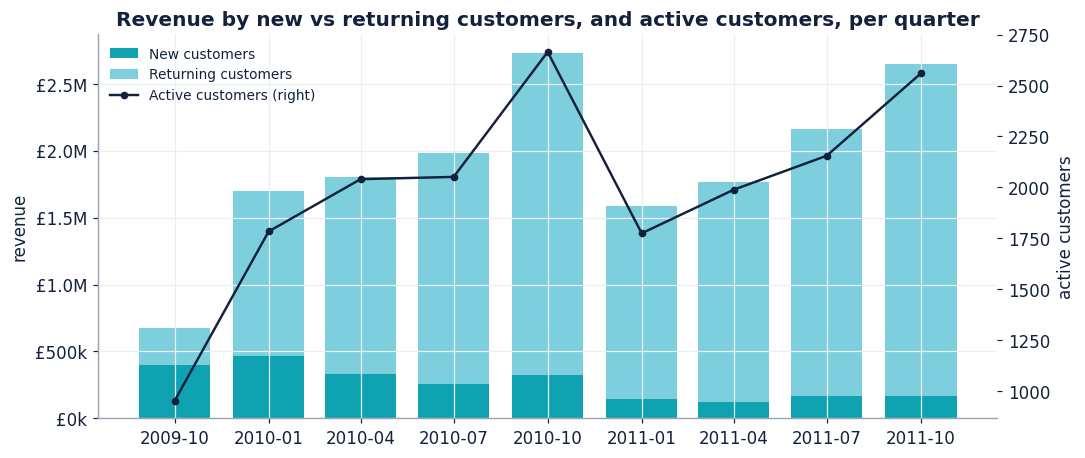

Returning customers = 86% of identified revenue over the whole period.
Active identified customers per quarter:
quarter
2009-10-01     951
2010-01-01    1783
2010-04-01    2040
2010-07-01    2051
2010-10-01    2665
2011-01-01    1774
2011-04-01    1988
2011-07-01    2155
2011-10-01    2559


In [7]:
ident = sales.dropna(subset=["Customer ID"]).copy()
# Roll lines up to orders (one row per invoice), then flag each order new vs returning.
order = (ident.groupby(["Customer ID", "Invoice"], as_index=False)
              .agg(date=("InvoiceDate", "min"), revenue=("Revenue", "sum")))
first_dt = order.groupby("Customer ID")["date"].transform("min")
order["type"] = np.where(order["date"] == first_dt, "New", "Returning")
order["quarter"] = order["date"].dt.to_period("Q").dt.to_timestamp()

q = order.groupby(["quarter", "type"])["revenue"].sum().unstack("type").fillna(0)
active = (ident.assign(quarter=ident["InvoiceDate"].dt.to_period("Q").dt.to_timestamp())
               .groupby("quarter")["Customer ID"].nunique())

fig, ax = plt.subplots(figsize=(10, 4.3))
ax.bar(q.index, q.get("New", 0), width=70, color=TEAL, label="New customers")
ax.bar(q.index, q.get("Returning", 0), width=70, bottom=q.get("New", 0), color=LBLUE, label="Returning customers")
ax2 = ax.twinx()
ax2.plot(active.index, active.values, color=NAVY, marker="o", ms=4, lw=1.6, label="Active customers (right)")
ax2.grid(False); ax2.set_ylabel("active customers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money)); ax.set_ylabel("revenue")
ax.set_title("Revenue by new vs returning customers, and active customers, per quarter")
h1,l1 = ax.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, frameon=False, loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()
ret_share = q.get("Returning", 0).sum() / q.sum().sum() * 100
print(f"Returning customers = {ret_share:.0f}% of identified revenue over the whole period.")
print("Active identified customers per quarter:\n" + active.astype(int).to_string())

**Read:** the business runs on its **existing base, not new acquisition** — returning customers
are about **86% of identified revenue**. The active-customer count grows through 2010 and then is
**roughly flat year-over-year** (peak quarters near 2,500–2,650 in both 2010 and 2011; the Q1 dips
are seasonal, and Q4 2011 is partial). So new customers are largely *replacing* churn rather than
expanding the base — which puts the emphasis on **retention and reactivation**, not just winning
new logos.

## 4. Products & categories

### 4a. Top products (net of returns)

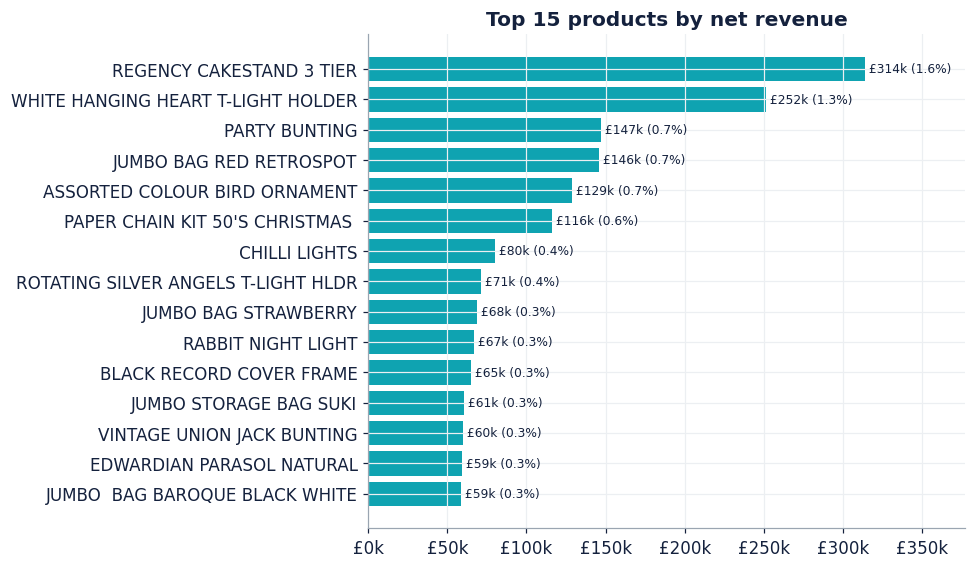

In [8]:
# Net revenue = sales minus returns, so an order that was placed then cancelled washes out.
s_desc = sales.groupby("Description")["Revenue"].sum()
r_desc = returns.groupby("Description")["Revenue"].sum()
net = s_desc.add(r_desc, fill_value=0).sort_values(ascending=False).head(15)[::-1]
tot = sales["Revenue"].sum()
fig, ax = plt.subplots(figsize=(9,5.3))
ax.barh(net.index, net.values, color=TEAL)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
for i,(nm,v) in enumerate(net.items()):
    ax.text(v, i, f" {money(v)} ({v/tot*100:.1f}%)", va="center", fontsize=8, color=NAVY)
ax.set_xlim(0, net.max()*1.2); ax.set_title("Top 15 products by net revenue")
plt.tight_layout(); plt.show()

### 4b. Category mix (derived)

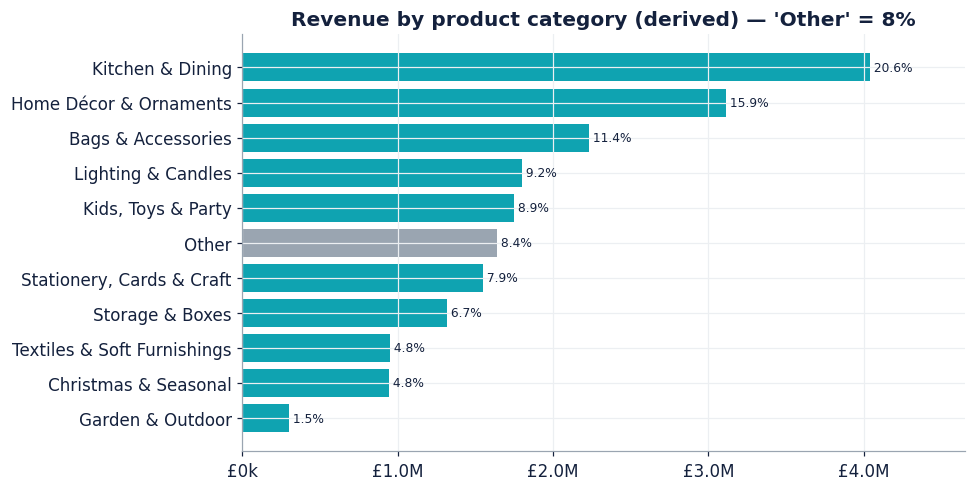

Kitchen & Dining + Home Décor = 36% of sales.


In [9]:
# No category field exists, so derive one from the Description text with ordered keyword rules
# (first match wins). This is a heuristic — about 8% of revenue falls into 'Other'.
RULES = [
 ("Christmas & Seasonal",  r"CHRISTMAS|XMAS|ADVENT|EASTER|HALLOWE|SANTA|REINDEER|SNOWMAN|NATIVITY"),
 ("Kids, Toys & Party",    r"TOY|KID|CHILDREN|PARTY|DOLL|GAME|PLAYHOUSE|SPACEBOY|SPACEGIRL|PIGGY|SKITTLE|JIGSAW|BALLOON|CRAYON|MODELLING|SKIPPING|SPINNING TOP|BINGO|SNAKES|COLOURING|FELTCRAFT|DOMINOES|CHALK|SLEDGE"),
 ("Lighting & Candles",    r"T-?LIGHT|TEA ?LIGHT|NIGHT ?LIGHT| LIGHT|LIGHTS|LANTERN|CANDLE|LAMP|LED |FAIRY LIGHT"),
 ("Kitchen & Dining",      r"MUG|CUP|BOWL|PLATE|TEAPOT|TEA SET|TEA GLASS|CAKE|BAKING|JUG|CUTLER|TEA TOWEL|BOTTLE|JAR|TRAY|EGG|KITCHEN|SPOON|COOK|CANISTER|COFFEE|SAUCER|MOULD|JELLY|JAM MAKING|PANTRY|RECIPE|COLANDER|TEACUP"),
 ("Textiles & Soft Furnishings", r"CUSHION|PAD|THROW|BLANKET|RUG|TOWEL|NAPKIN|PLACEMAT|TEA COSY|HOT WATER BOTTLE|DOORMAT|HAND WARMER|APRON"),
 ("Bags & Accessories",    r"BAG|SHOPPER|TOTE|CASH\+CARRY|PURSE|WALLET|NECKLACE|BRACELET|EARRING|BANGLE|SCARF|GLOVE|UMBRELLA|PARASOL|HAT|KEY FOB|KEYRING|SILK FAN"),
 ("Stationery, Cards & Craft", r"CARD|NOTEBOOK|PAPER|WRAP|PEN |PENCIL|CHALKBOARD|STICKER|POSTCARD|GREETING|NOTELET|GIFT TAG|ENVELOPE|RIBBON|CRAFT|SEWING|FELT|GLITTER|TISSUE|DOILY|STATIONERY"),
 ("Home Décor & Ornaments", r"HEART|HANGING|DECORATION|ORNAMENT|FRAME|MIRROR|CLOCK|SIGN|VASE|HOOK|DOORSTOP|WALL ART|CANDLESTICK|BUNTING|GARLAND|BLOCK WORD|WICKER|CHANDELIER|CABINET|WOODEN STAR"),
 ("Storage & Boxes",       r"BOX|TIN|STORAGE|BASKET|TRUNK|DRAWER|CRATE|HOLDER|RACK|CADDY|CASE"),
 ("Garden & Outdoor",      r"GARDEN|PLANT|WATERING|BIRD|DECKCHAIR|FLOWER|WINDMILL|SEED"),
]
def categorize(desc):
    d = str(desc).upper()
    for cat, pat in RULES:
        if re.search(pat, d):
            return cat
    return "Other"
cat_map = {d: categorize(d) for d in sales["Description"].dropna().unique()}
sales["category"] = sales["Description"].map(cat_map).fillna("Other")

cat = sales.groupby("category")["Revenue"].sum().sort_values()
fig, ax = plt.subplots(figsize=(9,4.6))
ax.barh(cat.index, cat.values, color=[GRAY if c=="Other" else TEAL for c in cat.index])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
for i,(c,v) in enumerate(cat.items()):
    ax.text(v, i, f" {v/cat.sum()*100:.1f}%", va="center", fontsize=8, color=NAVY)
ax.set_xlim(0, cat.max()*1.15)
ax.set_title(f"Revenue by product category (derived) — 'Other' = {cat['Other']/cat.sum()*100:.0f}%")
plt.tight_layout(); plt.show()
print(f"Kitchen & Dining + Home Décor = {(cat.get('Kitchen & Dining',0)+cat.get('Home Décor & Ornaments',0))/cat.sum()*100:.0f}% of sales.")

Categories are a **heuristic** from messy free text (about 8% land in 'Other'), so read them as directional. **Kitchen & Dining (about 21%) and Home Décor (about 16%)** lead the mix.

### 4c. Category sales trends over time

How each leading category's revenue moves quarter-to-quarter (the final quarter of 2011 is partial — Dec cut off — so treat its dip with care).

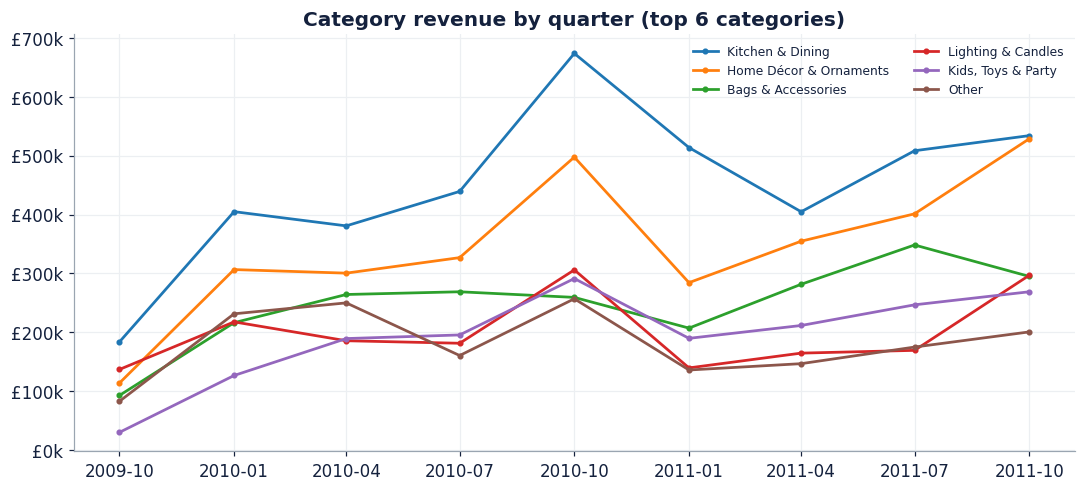

In [10]:
salesq = sales.assign(quarter=sales["InvoiceDate"].dt.to_period("Q").dt.to_timestamp())
top_cats = sales.groupby("category")["Revenue"].sum().sort_values(ascending=False).head(6).index
ct = (salesq[salesq["category"].isin(top_cats)]
      .groupby(["quarter", "category"])["Revenue"].sum().unstack("category"))
fig, ax = plt.subplots(figsize=(10, 4.6))
for c in top_cats:
    ax.plot(ct.index, ct[c], marker="o", ms=3, lw=1.8, label=c)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money))
ax.set_title("Category revenue by quarter (top 6 categories)")
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

**Read:** the leading categories move **together** on the same autumn ramp, with **Kitchen &
Dining** and **Home Décor** consistently on top and the relative order stable across the window —
no category runs away from the pack. The dip in the final quarter is the **truncated December**
(data ends 9 Dec 2011), not a real fall-off.

### 4d. Emerging vs declining categories

A like-for-like **year-over-year** comparison. We use the **Jan–Nov window of 2010 vs 2011** (both complete) to avoid the truncated Decembers. With only two years this is a *single* comparison — directional, not a trend line.

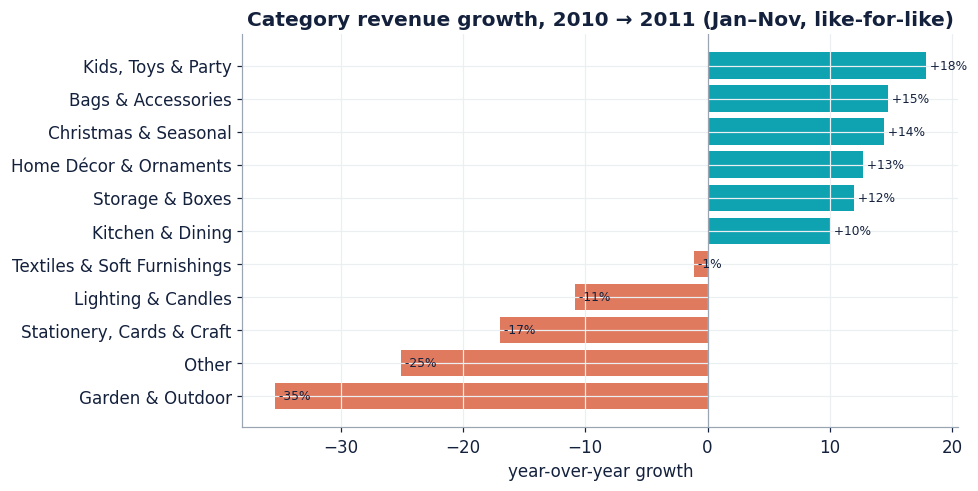

Category growth 2010->2011 (Jan-Nov, %):
category
Kids, Toys & Party             18.0
Bags & Accessories             15.0
Christmas & Seasonal           14.0
Home Décor & Ornaments         13.0
Storage & Boxes                12.0
Kitchen & Dining               10.0
Textiles & Soft Furnishings    -1.0
Lighting & Candles            -11.0
Stationery, Cards & Craft     -17.0
Other                         -25.0
Garden & Outdoor              -35.0

Fastest-growing products (2010→2011, >£2k base):
Description
PAPER BUNTING RETROSPOT         710.0
LUNCH BAG PINK POLKADOT         684.0
LUNCH BAG RED RETROSPOT         510.0
HOMEMADE JAM SCENTED CANDLES    505.0
RED RETROSPOT CHARLOTTE BAG     498.0

Fastest-declining products:
Description
EASTER CRAFT IVY WREATH WITH CHICK   -100.0
FRYING PAN RED POLKADOT              -100.0
CHRISTMAS RETROSPOT HEART WOOD       -100.0
RED WHITE SCARF  HOT WATER BOTTLE    -100.0
CREAM SWEETHEART WALL CABINET        -100.0


In [11]:
# Matched Jan-Nov window, 2010 vs 2011, so the Dec truncation doesn't distort growth.
win = sales[(sales["InvoiceDate"].dt.month <= 11) & (sales["InvoiceDate"].dt.year.isin([2010, 2011]))]
cat_yoy = (win.assign(year=win["InvoiceDate"].dt.year)
              .groupby(["category", "year"])["Revenue"].sum().unstack("year").dropna())
cat_yoy["growth_%"] = (cat_yoy[2011] / cat_yoy[2010] - 1) * 100
cat_yoy = cat_yoy.sort_values("growth_%")
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(cat_yoy.index, cat_yoy["growth_%"],
        color=[CORAL if g < 0 else TEAL for g in cat_yoy["growth_%"]])
ax.axvline(0, color=GRAY, lw=0.8)
for i, (c, g) in enumerate(cat_yoy["growth_%"].items()):
    ax.text(g, i, f" {g:+.0f}%", va="center", fontsize=8, color=NAVY)
ax.set_title("Category revenue growth, 2010 → 2011 (Jan–Nov, like-for-like)")
ax.set_xlabel("year-over-year growth")
plt.tight_layout(); plt.show()

# Fastest-moving individual products (ignore tiny 2010 bases to avoid noisy ratios).
sku = (win.assign(year=win["InvoiceDate"].dt.year)
          .groupby(["Description", "year"])["Revenue"].sum().unstack("year").dropna())
sku = sku[sku[2010] > 2000]; sku["growth_%"] = (sku[2011] / sku[2010] - 1) * 100
print("Category growth 2010->2011 (Jan-Nov, %):")
print(cat_yoy["growth_%"].round(0).sort_values(ascending=False).to_string())
print()
print("Fastest-growing products (2010→2011, >£2k base):")
print(sku.sort_values("growth_%", ascending=False).head(5)["growth_%"].round(0).to_string())
print("\nFastest-declining products:")
print(sku.sort_values("growth_%").head(5)["growth_%"].round(0).to_string())

**Read (like-for-like Jan–Nov, 2010 → 2011):**

- **Emerging:** Kids, Toys & Party (**+18%**), Bags & Accessories (**+15%**), Christmas & Seasonal
  (**+14%**) and Home Décor (**+13%**) lead growth — even the large Kitchen category grew +10%.
  At the product level the risers are **bag lines** (Lunch Bag / Charlotte Bag) and the
  **"Retrospot" range**, which is clearly on-trend.
- **Declining:** Garden & Outdoor (**−35%**), Stationery/Cards/Craft (**−17%**) and Lighting &
  Candles (**−11%**). The −100% products are lines that were effectively **discontinued**.

*Caveat:* this is a **single** year-over-year comparison (only two years of data) and categories
are a text heuristic — treat as directional, not a trend.

## 5. Pricing behaviour — the same product costs less in bulk

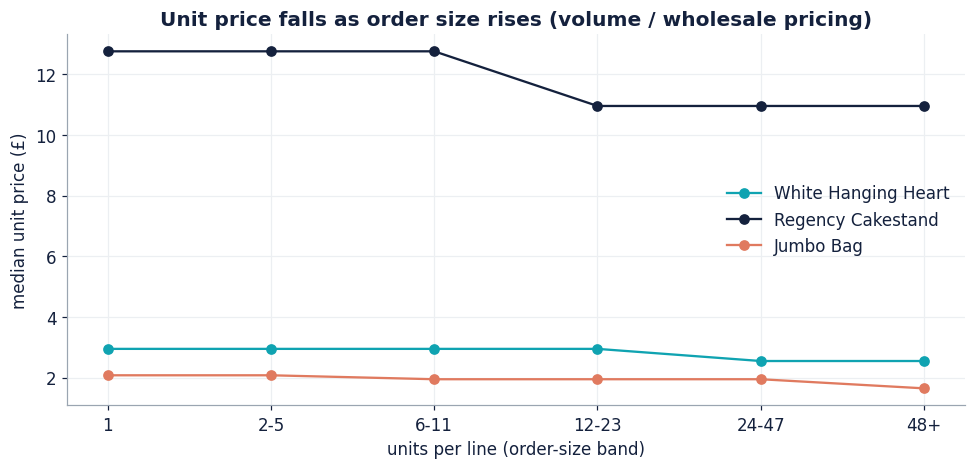

The same SKU sells cheaper in larger quantities — order size, not customer identity,
explains most of the price spread. (A formal price~quantity test could confirm.)


In [12]:
# For a few high-volume SKUs, median unit price by order-size band shows a clear volume discount.
def band(q):
    return ("1" if q==1 else "2-5" if q<=5 else "6-11" if q<=11 else
            "12-23" if q<=23 else "24-47" if q<=47 else "48+")
order_bands = ["1","2-5","6-11","12-23","24-47","48+"]
ex = sales[sales["StockCode"].isin(["85123A","22423","85099B"])].copy()
ex["qb"] = ex["Quantity"].map(band)
labels = {"85123A":"White Hanging Heart","22423":"Regency Cakestand","85099B":"Jumbo Bag"}
piv = ex.pivot_table(index="qb", columns="StockCode", values="Price", aggfunc="median").reindex(order_bands)
fig, ax = plt.subplots()
for code_, col in zip(["85123A","22423","85099B"], [TEAL,NAVY,CORAL]):
    ax.plot(piv.index, piv[code_], marker="o", color=col, label=labels[code_])
ax.set_title("Unit price falls as order size rises (volume / wholesale pricing)")
ax.set_xlabel("units per line (order-size band)"); ax.set_ylabel("median unit price (£)"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print("The same SKU sells cheaper in larger quantities — order size, not customer identity,")
print("explains most of the price spread. (A formal price~quantity test could confirm.)")

## 6. Returns — modest but rising

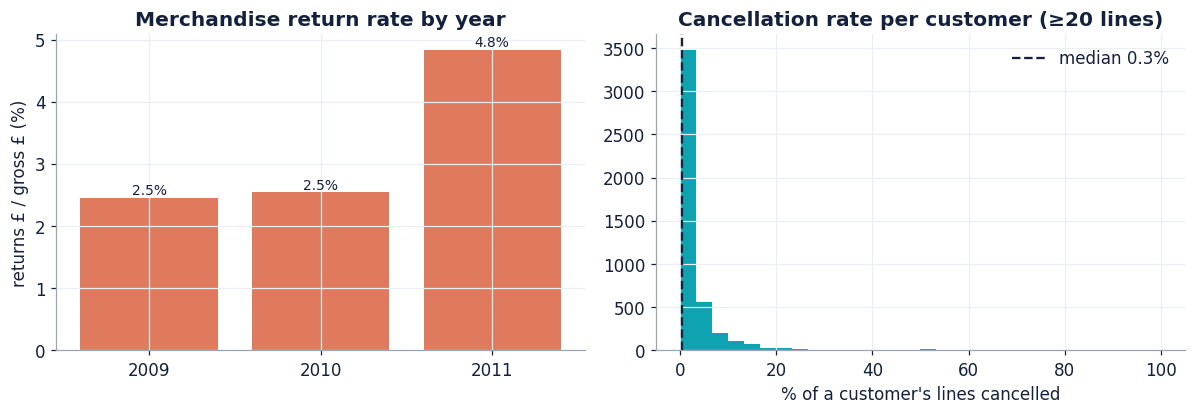

return rate by year: {2009: 2.5, 2010: 2.5, 2011: 4.8} | customers cancelling >50% of lines: 4


In [13]:
# Merchandise return VALUE as a share of gross sales, by year.
returns["year"] = returns["InvoiceDate"].dt.year
gy = sales.assign(y=sales["InvoiceDate"].dt.year).groupby("y")["Revenue"].sum()
ry = returns.groupby("year")["Revenue"].sum().reindex(gy.index).fillna(0)
rate = (-ry / gy * 100)

# How cancellations spread across customers (customers with >= 20 lines, to be fair).
cc = prep[prep["Customer ID"].notna()].copy()
by = cc.groupby("Customer ID").agg(n=("Invoice","size"), c=("is_cancellation","sum"))
by = by[by["n"] >= 20]; by["r"] = by["c"] / by["n"] * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
axes[0].bar(rate.index.astype(int).astype(str), rate.values, color=CORAL)
for x,v in zip(rate.index.astype(int).astype(str), rate.values):
    axes[0].text(x, v+0.05, f"{v:.1f}%", ha="center", color=NAVY, fontsize=9)
axes[0].set_title("Merchandise return rate by year"); axes[0].set_ylabel("returns £ / gross £ (%)")
axes[1].hist(by["r"], bins=30, color=TEAL)
axes[1].axvline(by["r"].median(), color=NAVY, ls="--", label=f"median {by['r'].median():.1f}%")
axes[1].set_title("Cancellation rate per customer (≥20 lines)")
axes[1].set_xlabel("% of a customer's lines cancelled"); axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()
print("return rate by year:", {int(k):round(v,1) for k,v in rate.items()},
      f"| customers cancelling >50% of lines: {(by['r']>50).sum()}")

## 7. Deeper analysis

The sections so far describe *what* happened. These four go a level deeper into *who* the
customers are and *what we can act on*:

- **7a. RFM segmentation** — group customers by recency, frequency and spend.
- **7b. Cohort retention** — do customers come back, and how fast does that decay?
- **7c. Market-basket affinity** — which products are bought together?
- **7d. A repeat-purchase model** — can we predict, from a first order, who will buy again?

Each notes whether the data can actually support the technique before interpreting it.

### 7a. Customer segments (RFM)

**What is RFM?** A standard, transparent way to segment customers by *behaviour* using three
signals:

- **Recency (R)** — how recently they last purchased (days since last order, vs the day after the
  final date in the data). More recent is better.
- **Frequency (F)** — how often they purchase (number of distinct invoices).
- **Monetary (M)** — how much they spend in total.

**How we score.** Rank each of R, F, M into **quintiles 1–5** (Recency reversed so 5 = most
recent). **How segments are named** — from the R and F scores, using simple rules:

| Segment | Rule | Meaning |
|---|---|---|
| **Champions** | R ≥ 4 and F ≥ 4 | recent *and* frequent |
| **Loyal** | R ≥ 3 and F ≥ 3 | solidly active |
| **New / promising** | R ≥ 4 and F ≤ 2 | recent, not yet frequent |
| **At risk (was frequent)** | R ≤ 2 and F ≥ 3 | used to buy often, gone quiet |
| **Hibernating** | R ≤ 2 and F ≤ 2 | not recent, not frequent |
| **Needs attention** | everything else | mid-range |

**Is the data enough?** Yes for a **snapshot** segmentation: two years of transactions give a
stable read of each customer's recency/frequency/spend. Caveats: it's a single snapshot against a
fixed end-date, and the about 23% of unattributed sales are excluded (so this describes the *identified*
base only).

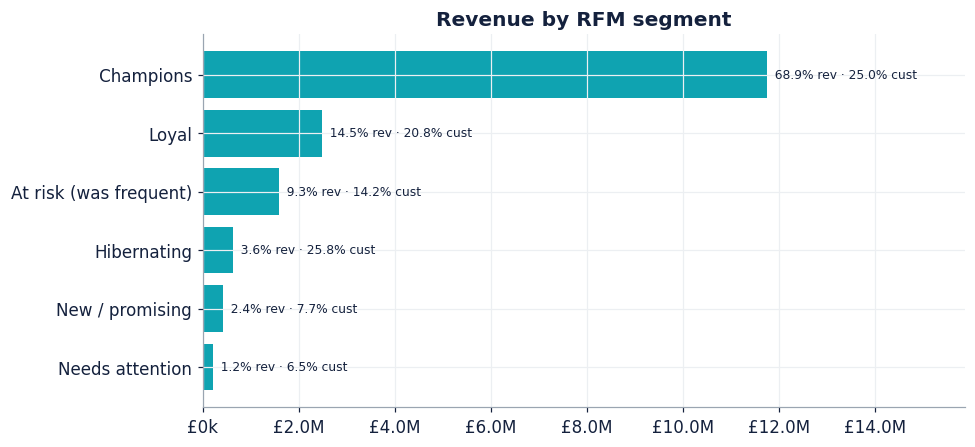

                        customers  cust_%  rev_%
segment                                         
Champions                    1463    25.0   68.9
Loyal                        1218    20.8   14.5
At risk (was frequent)        830    14.2    9.3
Hibernating                  1511    25.8    3.6
New / promising               448     7.7    2.4
Needs attention               382     6.5    1.2


In [14]:
# Recency / Frequency / Monetary per identified customer.
snapshot = sales["InvoiceDate"].max() + pd.Timedelta(days=1)      # "today" for recency
rfm = sales.dropna(subset=["Customer ID"]).groupby("Customer ID").agg(
    recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
    frequency=("Invoice", "nunique"),
    monetary=("Revenue", "sum"))
# Quintile scores 1-5 (rank first to avoid duplicate bin edges); recency reversed.
rfm["R"] = pd.qcut(rfm["recency"].rank(method="first"), 5, labels=[5,4,3,2,1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
def segment(r):
    R, F = r["R"], r["F"]
    if R >= 4 and F >= 4: return "Champions"
    if R >= 3 and F >= 3: return "Loyal"
    if R >= 4 and F <= 2: return "New / promising"
    if R <= 2 and F >= 3: return "At risk (was frequent)"
    if R <= 2 and F <= 2: return "Hibernating"
    return "Needs attention"
rfm["segment"] = rfm.apply(segment, axis=1)

seg = rfm.groupby("segment").agg(customers=("recency","size"), revenue=("monetary","sum"))
seg["rev_%"]  = (seg["revenue"]/seg["revenue"].sum()*100).round(1)
seg["cust_%"] = (seg["customers"]/seg["customers"].sum()*100).round(1)
seg = seg.sort_values("revenue")
fig, ax = plt.subplots(figsize=(9,4.2))
ax.barh(seg.index, seg["revenue"].values, color=TEAL)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
for i,(s,row) in enumerate(seg.iterrows()):
    ax.text(row["revenue"], i, f"  {row['rev_%']}% rev · {row['cust_%']}% cust", va="center", fontsize=8, color=NAVY)
ax.set_xlim(0, seg["revenue"].max()*1.35); ax.set_title("Revenue by RFM segment")
plt.tight_layout(); plt.show()
print(seg[["customers","cust_%","rev_%"]].sort_values("rev_%", ascending=False).to_string())

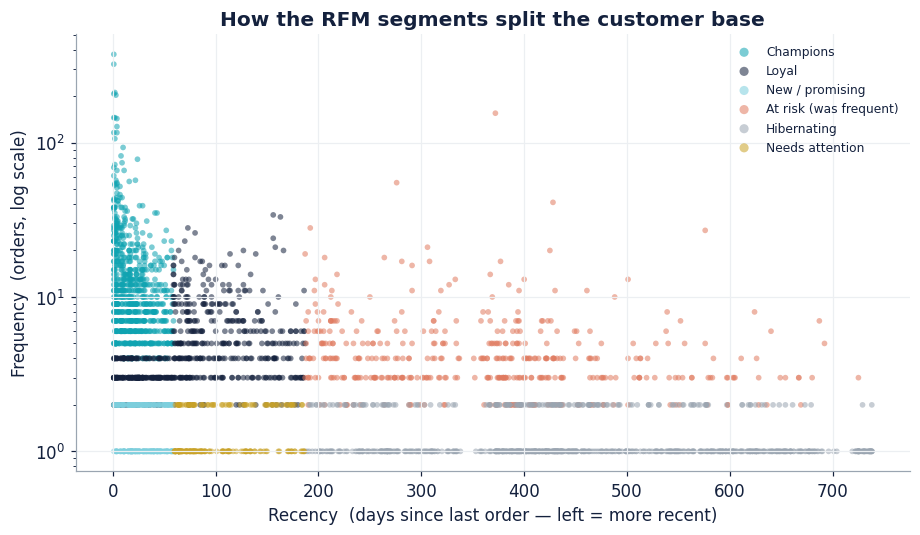

In [15]:
# Visualise what the rules carve up: Recency vs Frequency, coloured by segment.
seg_order = ["Champions","Loyal","New / promising","At risk (was frequent)","Hibernating","Needs attention"]
palette = {"Champions":TEAL, "Loyal":NAVY, "New / promising":LBLUE,
           "At risk (was frequent)":CORAL, "Hibernating":GRAY, "Needs attention":"#C9A227"}
samp = rfm.sample(min(3000, len(rfm)), random_state=1)
fig, ax = plt.subplots(figsize=(8.5, 5))
for s in seg_order:
    d = samp[samp["segment"]==s]
    ax.scatter(d["recency"], d["frequency"], s=14, alpha=0.55, color=palette[s], label=s, edgecolors="none")
ax.set_yscale("log")
ax.set_xlabel("Recency  (days since last order — left = more recent)")
ax.set_ylabel("Frequency  (orders, log scale)")
ax.set_title("How the RFM segments split the customer base")
ax.legend(frameon=False, fontsize=8, markerscale=1.6, loc="upper right")
plt.tight_layout(); plt.show()

**Read:** the base is top-heavy. **Champions are about 25% of customers but 69% of revenue**;
together with **Loyal** (21% of customers, 15% of revenue) the top two segments — roughly **46% of
customers — drive about 83% of revenue**. At the other end, a large **Hibernating** tail (about 26%
of customers) contributes only about 4%. The scatter shows the clean split (recent + frequent
Champions bottom-left; distant, infrequent Hibernating to the right). **Actionable:** protect
Champions, win back the **At-risk (was frequent)** group (14% of customers, 9% of revenue), and
don't over-invest in the Hibernating tail.

### 7b. Cohort retention — with a big caveat

**What a cohort shows:** group customers by the month of their **first** purchase, then track the
share who order again in each later month.

**Can the data support this reliably? Only partly — two problems:**

1. **Left-censoring.** The data starts in December 2009, so a customer's *first observed* order may
   not be their *true* first order — the earliest cohorts are contaminated. We drop the Dec-2009
   cohort and read the rest as directional.
2. **Wholesale cadence.** Wholesalers reorder **irregularly** (every few months), so a strict
   "active *this month*" measure understates engagement — a customer who reorders quarterly looks
   "churned" in the off-months. So monthly retention here reflects **reorder cadence**, not pure
   churn. (The eventual-repeat rate in §7d — most customers *do* come back — is the better churn read.)

Given that, we show the **average reorder rate by months-since-first-purchase** (clearer than a
triangular heatmap):

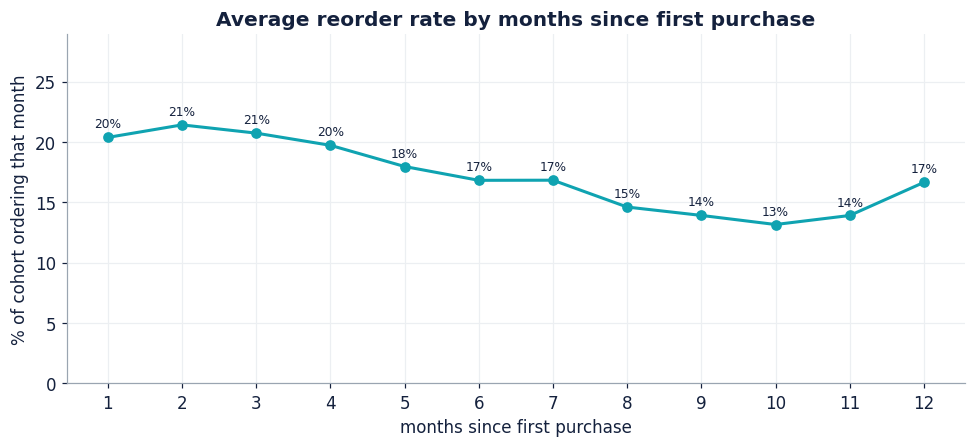

month 1: 20%   month 6: 17%   month 12: 17%


In [16]:
c = sales.dropna(subset=["Customer ID"]).copy()
c["order_month"] = c["InvoiceDate"].dt.to_period("M")
first = c.groupby("Customer ID")["order_month"].min().rename("cohort")
c = c.join(first, on="Customer ID")
c["k"] = (c["order_month"].dt.year - c["cohort"].dt.year)*12 + (c["order_month"].dt.month - c["cohort"].dt.month)
counts = c.groupby(["cohort", "k"])["Customer ID"].nunique().unstack()
retention = counts.divide(counts[0], axis=0) * 100
# Average across cohorts, excluding the left-censored Dec-2009 cohort; months 1..12.
avg = retention.drop(index=retention.index.min()).iloc[:, 1:13].mean()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(avg.index, avg.values, marker="o", color=TEAL, lw=2)
for x, y in zip(avg.index, avg.values):
    ax.text(x, y+0.8, f"{y:.0f}%", ha="center", fontsize=8, color=NAVY)
ax.set_ylim(0, max(avg.values)*1.35); ax.set_xticks(range(1, 13))
ax.set_title("Average reorder rate by months since first purchase")
ax.set_xlabel("months since first purchase"); ax.set_ylabel("% of cohort ordering that month")
plt.tight_layout(); plt.show()
print(f"month 1: {avg.iloc[0]:.0f}%   month 6: {avg.loc[6]:.0f}%   month 12: {avg.loc[12]:.0f}%")

**Read:** after the first month the reorder rate settles at roughly **17–20% per month** and
stays flat out to month 12 — in any given month only about 1 in 5 of a cohort orders. Read as
**reorder cadence, not churn**: §7d shows about **72% of customers eventually return**, so most
aren't lost — they simply buy **sporadically**, exactly as expected for wholesale restocking. The
*flatness* (no steady decay) points to a stable long-run reorder propensity. Given the
left-censoring and cadence caveats above, this is **directional**; a "reordered within N months"
measure would be a sounder churn metric.

### 7c. Market-basket / product affinity

**The question:** which products tend to appear in the **same order (invoice)**? For the most
common products we count how often each pair is bought together, then compute:

- **Support** — the share of orders that contain the pair (how common it is).
- **Lift** — how much more often the pair occurs together than if the two products were bought
  independently: `lift = P(A and B) / (P(A) × P(B))`. **Lift > 1 = bought together more than
  chance** (a genuine affinity); lift ≈ 1 = no relationship.

We restrict to the **top roughly 60 products** so pairs have enough support to be meaningful, require at
least 40 shared baskets, and rank by lift.

                            product_A                          product_B  baskets  support_%  lift
0            RED SPOTTY CHARLOTTE BAG   CHARLOTTE BAG , PINK/WHITE SPOTS     1077        3.7   9.7
1              WOODLAND CHARLOTTE BAG        CHARLOTTE BAG , SUKI DESIGN      838        2.9   8.9
2      SWEETHEART CERAMIC TRINKET BOX     STRAWBERRY CERAMIC TRINKET BOX     1109        3.8   8.9
3              WOODLAND CHARLOTTE BAG   CHARLOTTE BAG , PINK/WHITE SPOTS      764        2.6   8.9
4      JUMBO BAG SCANDINAVIAN PAISLEY     JUMBO BAG PINK VINTAGE PAISLEY      757        2.6   8.8
5         CHARLOTTE BAG , SUKI DESIGN   CHARLOTTE BAG , PINK/WHITE SPOTS      833        2.9   8.7
6              WOODLAND CHARLOTTE BAG           RED SPOTTY CHARLOTTE BAG      926        3.2   8.4
7          CHOCOLATE HOT WATER BOTTLE  HOT WATER BOTTLE TEA AND SYMPATHY      776        2.7   8.2
8   WOODEN PICTURE FRAME WHITE FINISH        WOODEN FRAME ANTIQUE WHITE      1078        3.7   7.9
9         

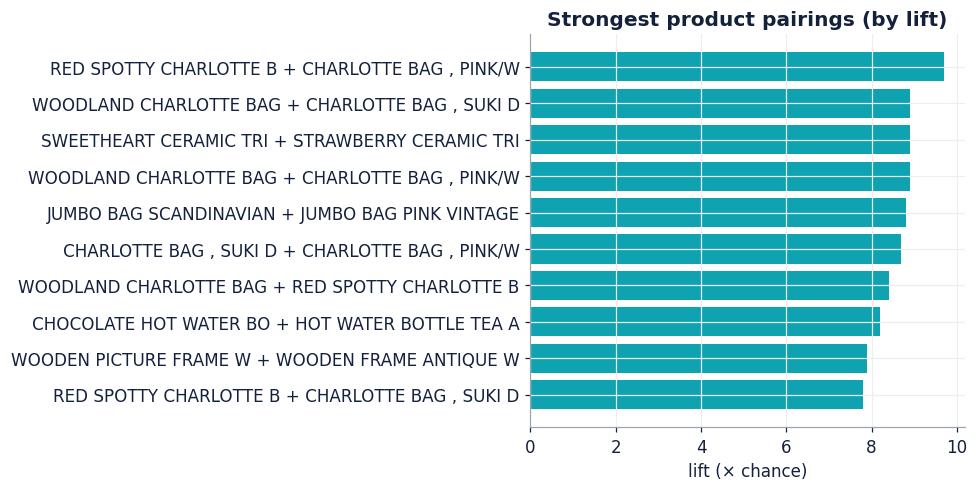

In [17]:
top_n = sales["StockCode"].value_counts().head(60).index          # focus on common products
basket = sales[sales["StockCode"].isin(top_n)]
pair, item = Counter(), Counter()                                  # co-occurrence counters
for _, grp in basket.groupby("Invoice")["StockCode"]:
    items = set(grp)
    for it in items: item[it] += 1
    for a, b in combinations(sorted(items), 2): pair[(a, b)] += 1
n_inv = basket["Invoice"].nunique()
desc = sales.drop_duplicates("StockCode").set_index("StockCode")["Description"]
rows = []
for (a, b), cnt in pair.items():
    lift = (cnt / n_inv) / ((item[a] / n_inv) * (item[b] / n_inv))
    rows.append((desc.get(a, a), desc.get(b, b), cnt, round(cnt/n_inv*100, 1), round(lift, 1)))
aff = (pd.DataFrame(rows, columns=["product_A","product_B","baskets","support_%","lift"])
         .query("baskets >= 40").sort_values("lift", ascending=False).head(12).reset_index(drop=True))
print(aff.to_string())
top10 = aff.head(10)[::-1]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh([f"{a[:22]} + {b[:22]}" for a, b in zip(top10["product_A"], top10["product_B"])],
        top10["lift"], color=TEAL)
ax.set_title("Strongest product pairings (by lift)"); ax.set_xlabel("lift (× chance)")
plt.tight_layout(); plt.show()

**Read:** the strongest pairings (lift **7–10×**, i.e. bought together 7–10 times more than
chance) are **within product ranges and colourways** — the Charlotte Bag variants, Jumbo Bag
paisley variants, matching ceramic trinket boxes, paired wooden frames, small+large wicker hearts,
and the "HOME"/"LOVE" building-block words. These are clear, actionable **bundling and cross-sell**
signals: sell ranges as sets and recommend the matching colourway. *Caveat:* restricted to the
top roughly 60 products, and affinity is association (a wholesaler naturally orders a whole range), not
causation.

### 7d. A first predictive baseline — will a customer buy again?

**Setup.** Using **only what we know from a customer's very first order** (so there's no
leakage from the future), predict whether they ever place a **second** order.

**Why these features** — each is available at the moment of the first order and plausibly relates
to repurchase:

- **first-order value / items / distinct products** — a bigger, broader first order suggests a
  more committed (often wholesale) buyer;
- **average unit price** — proxies wholesale vs. retail pricing;
- **month of first order** — captures whether they were acquired in the busy season;
- **is-UK** — domestic vs. overseas buyers behave differently.

**Label:** 1 if the customer placed 2+ distinct orders overall. **Models:** random forest +
logistic regression (class-weighted), scored by **ROC-AUC** on a held-out 25% (0.5 = chance).
We read **RF feature importance** (which features the model leans on) alongside **logistic
coefficients** (direction + strength on standardised features) to judge what actually matters.

In [18]:
# Build one row per customer from their FIRST order only (no post-first-order information).
c = sales.dropna(subset=["Customer ID"]).copy()
n_orders   = c.groupby("Customer ID")["Invoice"].nunique()
first_date = c.groupby("Customer ID")["InvoiceDate"].transform("min")
first_lines = c[c["InvoiceDate"] == first_date]                    # the lines of each customer's first order
feat = first_lines.groupby("Customer ID").agg(
    first_value=("Revenue", "sum"), first_items=("Quantity", "sum"),
    first_distinct=("StockCode", "nunique"), first_avg_price=("Price", "mean"),
    first_month=("InvoiceDate", lambda s: s.dt.month.iloc[0]),
    is_uk=("Country", lambda s: int((s == "United Kingdom").iloc[0])))
feat["label"] = (n_orders.reindex(feat.index) >= 2).astype(int)   # did they come back?
print(f"customers: {len(feat):,} | base repeat rate: {feat['label'].mean()*100:.0f}%")
feat.head()

customers: 5,852 | base repeat rate: 72%


,first_value,first_items,first_distinct,first_avg_price,first_month,is_uk,label
Customer ID,,,,,,,
12346,27.05,5,5,5.410000,3,1,1
12347,611.53,509,40,1.834000,10,0,1
12348,221.16,372,19,0.704737,9,0,1
12349,1068.52,473,46,4.230000,4,0,1
12350,294.40,196,16,1.581250,2,0,0


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

X = feat[["first_value","first_items","first_distinct","first_avg_price","first_month","is_uk"]]
y = feat["label"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
rf    = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42).fit(Xtr, ytr)
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")).fit(Xtr, ytr)
auc_rf = roc_auc_score(yte, rf.predict_proba(Xte)[:,1])
auc_lr = roc_auc_score(yte, logit.predict_proba(Xte)[:,1])
print(f"ROC-AUC — random forest: {auc_rf:.2f} | logistic: {auc_lr:.2f}")
# Logistic coefficients (standardised features -> comparable; sign = direction).
coef = pd.Series(logit.named_steps["logisticregression"].coef_[0], index=X.columns).sort_values()
print("\nLogistic coefficients (standardised; + = raises repeat probability):")
print(coef.round(2).to_string())

ROC-AUC — random forest: 0.68 | logistic: 0.61

Logistic coefficients (standardised; + = raises repeat probability):
first_month       -0.14
first_avg_price   -0.10
first_items       -0.09
is_uk              0.09
first_distinct     0.13
first_value        0.25


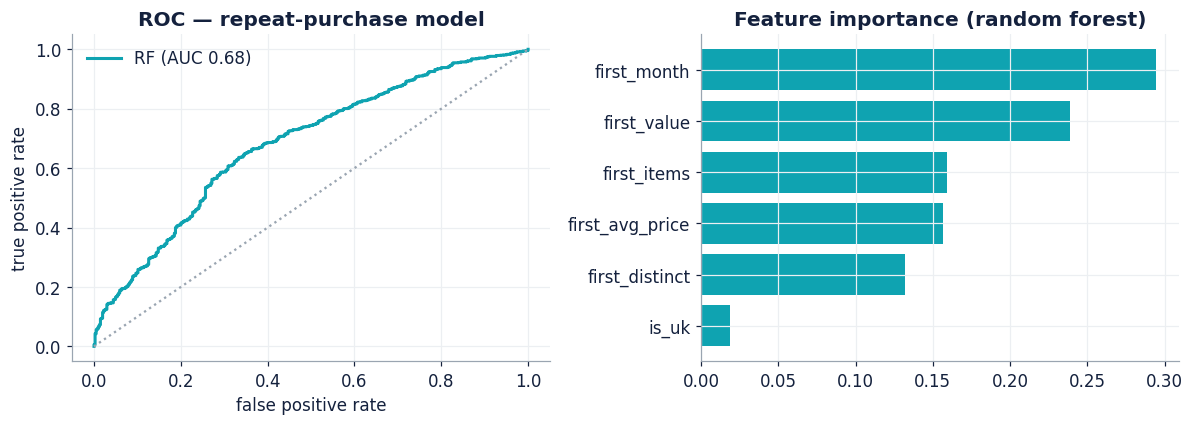

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fpr, tpr, _ = roc_curve(yte, rf.predict_proba(Xte)[:,1])
axes[0].plot(fpr, tpr, color=TEAL, lw=2, label=f"RF (AUC {auc_rf:.2f})")
axes[0].plot([0,1],[0,1], color=GRAY, ls=":"); axes[0].legend(frameon=False)
axes[0].set_title("ROC — repeat-purchase model"); axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
axes[1].barh(imp.index, imp.values, color=TEAL); axes[1].set_title("Feature importance (random forest)")
plt.tight_layout(); plt.show()

**Read:** the model is **better than chance but only modestly** (AUC about **0.68** for the
random forest, 0.61 for logistic) — and with a **72% base repeat rate**, first-order behaviour
alone is a **weak predictor** of whether someone returns. What does matter, consistently across
both models: a larger **first-order value** (strongest signal, +0.25 standardised coefficient) and
a **broader first order** (more distinct products, +0.13) raise repeat probability — i.e. bigger,
more committed (often wholesale) first orders are likelier to come back; being UK-based is mildly
positive. **Takeaway:** you can't reliably predict repeat at acquisition from these features; a
useful model needs **behavioural + timing signals** (inter-order gaps, engagement) and a
time-based validation split. The better business framing is *when / how often* customers return,
not simply *whether*.

## 8. Findings & hypotheses

| # | Finding / hypothesis | Why it matters | Confidence |
|---|----------------------|----------------|-----------|
| 1 | **Revenue is highly concentrated** — UK about 86% of revenue, top 20% of customers about 77%, and Champions (25% of customers) about 69%; unit price falls with order size (wholesale pricing). | A lost account is a revenue event; account management beats broad acquisition. | **Medium-High** |
| 2 | **Demand peaks in November**; December is truncated/unreliable. | Plan inventory & cash-flow around the autumn build-up. | **High** (Nov) |
| 3 | **The business runs on returning customers** (about 86% of revenue) and the **active base is roughly flat year-over-year**. | Growth depends on retention/reactivation, not just new customers. | **Medium-High** |
| 4 | **Purchasing is irregular but repeat-heavy** — about 17–20% reorder in any month, yet about 72% return within two years; a first-order model is weak (AUC about 0.68). | The lever is reorder timing/frequency; predict/drive repeat with behavioural data. | **Medium** |
| 5 | **Category growth is broad in gifting/bags** (Kids +18%, Bags +15%, Christmas +14%, Home +13%) while **Garden (−35%), Stationery (−17%), Lighting (−11%) decline**; Kitchen + Home are about 37% of sales. | Steer range/inventory toward risers; review decliners. | **Medium** (heuristic categories, one YoY) |
| 6 | **Strong product-range affinities** (lift 7–10×) among colourway/range variants. | Concrete bundling & cross-sell opportunities. | **Medium** |
| 7 | **About 23% of sales are unattributed** and behave differently — possibly a separate retail/marketplace channel. | Customer metrics describe only the identified base. | **Medium** — needs confirmation |
| 8 | **Merchandise returns are modest but rising** (about 2.5% → 4.8%), with a small high-cancellation tail. | Forecast on net; review the worst accounts. | **Medium** |

## 9. Recommendations & next steps

1. **Protect and grow top accounts** — Champions + Loyal drive the large majority of revenue;
   monitor concentration and churn risk on these segments.
2. **Prioritise retention & reactivation over pure acquisition** — 86% of revenue is returning and
   the active base is flat; target the **At-risk (was frequent)** group and lapsed accounts, and
   measure with cohorts / a "reordered within N months" metric.
3. **Steer the range toward growth** — lean into Kids/Toys, Bags and seasonal/home lines
   (and the on-trend "Retrospot" range); review the declining Garden, Stationery and Lighting
   categories.
4. **Use product affinities for bundling / cross-sell** — sell ranges and matching colourways together.
5. **Plan around the autumn peak** — inventory and cash-flow for the September–November build-up.
6. **Close the data gaps** (from Notebook 1) — line-level ID, a channel flag for unattributed
   sales, and cost data to move from revenue to **margin**; then revisit the repeat-purchase model
   with behavioural features and a time-based split.